In [1]:
import numpy as np
import subprocess
from scipy.interpolate import RegularGridInterpolator
import astropy.units as u
from astropy.io import fits
from synphot import SourceSpectrum, Observation
from synphot.models import Empirical1D
import multiprocessing as mp
import emcee
import corner

import os
gd_folder = os.getcwd()+"/../../Calculations/SKIRTOR/"

import sys 
sys.path.append(gd_folder)
#from loadSKIRTOR_MRN77 import LoadSKIRTOR_MRN77
from loadSKIRTOR_MRN77_force_reg import LoadSKIRTOR_MRN77

sys.path.append("../utility_functions/")
from objectProperties import ObjectProperties
from readExtrapolatedSpectra import ReadExtrapolatedSpectra

sys.path.append("../../Filter_Curves/")
from readBands import ReadBands

sys.path.append("../../spec_modeling/")
from model_W0116_spec import model_W0116_spec

In [2]:
wid = "W0116-0505"

In [3]:
#Load the properties of the BHDs
op = ObjectProperties(wids=[wid])

In [4]:
#Load the bands.
bands = ReadBands()
for bname in bands.bandnames:
    print(bname, bands.bp[bname].barlam(), bands.bp[bname].fwhm(), bands.bp[bname].rectwidth())

R_SPECIAL 6501.229535920617 Angstrom 1159.881393925198 Angstrom 1624.9974574790472 Angstrom
I_BESS 7925.773360798338 Angstrom 1080.5202412457434 Angstrom 1433.1539789444323 Angstrom
v_HIGH 5531.691038305597 Angstrom 850.6231300284223 Angstrom 1195.0838113345558 Angstrom


In [5]:
#Load the spectra for each BHD, extended using the best-fit SED.
specs = ReadExtrapolatedSpectra()

Wavelength range for object W0019-1046 limited because of sky template
Spec-range: 3001.5 Angstrom - 5423.93 Angstrom
Sky-range: 3199.4 Angstrom - 6724.06 Angstrom
Wavelength range for object W0204-0506 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.70 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.
Wavelength range for object W0831+0140 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.45 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.


In [6]:
#Load the spectrum and model. 
spec, spec_model = model_W0116_spec(specs)

In [7]:
#Get the total fluxes from the spectrum convolution, as well as the continuum fluxes and the combined line fluxes. 
spec_full = SourceSpectrum(Empirical1D, points=spec.lam_obs, lookup_table=spec.flam, keep_neg=True)

total_flux = dict()
line_flux = dict()
for bname in op.pfrac[wid].keys():

    obs_full = Observation(spec_full, bands.bp[bname])
    total_flux[bname] = obs_full.effstim(flux_unit='flam')

    line_flux[bname] = dict()
    for line in spec_model.multi_line:
        name = line.line_name
        if line.sigma_v_fit < 1000.*u.km/u.s:
            name += "_narrow"
        else:
            name += "_broad"

        spec_line = SourceSpectrum(Empirical1D, points=spec.lam_obs, lookup_table=line.flam_line_model(spec.lam_rest), keep_neg=True)
        obs_line = Observation(spec_line, bands.bp[bname])
        line_flux[bname][name] = obs_line.effstim(flux_unit='flam')


In [8]:
#We need to create a polarization map for W0116. The rest of the scripts work with the chi^2 maps directly, but this is not useful as we will be modifying the measured v_band polarization. 
def get_p_map_bb(bands, specs, wid, pw):

    #Set the grid of values for the calculation. 
    tang_grid = np.arange(25., 60.+0.01, 0.5)*u.deg
    cang_grid = np.arange(10., 55.+0.01, 0.5)*u.deg
    iang_grid = np.arange(25., 90.+0.01, 0.5)*u.deg
    # tang_grid = np.arange(25., 60.+0.01, 10.)*u.deg
    # cang_grid = np.arange(10., 55.+0.01, 10.)*u.deg
    # iang_grid = np.arange(25., 90.+0.01, 1.0)*u.deg

    #Create the output array. We'll mask certain regions that are not technically allowed by the model. 
    p_map = np.ma.zeros((len(bands), len(tang_grid), len(cang_grid), len(iang_grid)))
    p_map.mask = np.zeros(p_map.shape, dtype=bool)

    for j, band in enumerate(bands):
        p_map[j,:,:,:] = pw.p_bb(band, tang_grid, cang_grid, iang_grid, specs.lam_obs[wid], specs.flam[wid], specs.specs.sp[wid].zspec)

    #Turn into percentages. 
    p_map *= 100

    return p_map, tang_grid, cang_grid, iang_grid


In [9]:
def save_p(p_map, band_names, tang_grid, cang_grid, iang_grid, wid, folder="maps"):

    if not os.path.exists(folder):
        subprocess.call(["mkdir",folder])
    
    fname = "{}/p_map_{}.fits".format(folder, wid)

    p_hdr = fits.Header()

    p_hdr['BANDS'] = " ".join(band_names)
    p_hdr['TANGGRID'] = " ".join(tang_grid.value.astype(str))
    p_hdr['TANGUNIT'] = tang_grid.unit._short_names[0]
    p_hdr['CANGGRID'] = " ".join(cang_grid.value.astype(str))
    p_hdr['CANGUNIT'] = cang_grid.unit._short_names[0]
    p_hdr['IANGGRID'] = " ".join(iang_grid.value.astype(str))
    p_hdr['IANGUNIT'] = iang_grid.unit._short_names[0]

    p_data_hdu = fits.PrimaryHDU(data=p_map.data)
    p_data_hdu.header.update(p_hdr)
    p_mask_hdu = fits.ImageHDU(data=p_map.mask.astype(int))

    hdul = fits.HDUList([p_data_hdu, p_mask_hdu])
    hdul.writeto(fname, overwrite=True)

    return

In [10]:
#Read the p map. 
#force_new = True
force_new = False
p_map = dict()
pw = LoadSKIRTOR_MRN77()
for wid in op.wids:
    bands_use = list()
    for band in op.pfrac[wid].keys():
        bands_use.append(bands.bp[band])

    fname = "maps/p_map_{}.fits".format(wid)
    if os.path.exists(fname) and not force_new:
        h = fits.open(fname)
        tang_grid = np.array(h[0].header['TANGGRID'].split()).astype(float)
        tang_grid = tang_grid * u.Unit(h[0].header['TANGUNIT'])
        cang_grid = np.array(h[0].header['CANGGRID'].split()).astype(float)
        cang_grid = cang_grid * u.Unit(h[0].header['CANGUNIT'])
        iang_grid = np.array(h[0].header['IANGGRID'].split()).astype(float)
        iang_grid = iang_grid * u.Unit(h[0].header['IANGUNIT'])
        p_map[wid] = np.ma.zeros((len(bands_use), len(tang_grid), len(cang_grid), len(iang_grid)))
        p_map[wid][:,:,:,:] = h[0].data
        p_map[wid].mask = h[1].data.astype(bool)
        print(wid, p_map[wid][0,0,0,0])
    else:
        p_map[wid], tang_grid, cang_grid, iang_grid = get_p_map_bb(bands_use, specs, wid, pw)
        print(wid, p_map[wid][0,0,0,0])
        save_p(p_map[wid], list(op.pfrac[wid].keys()), tang_grid, cang_grid, iang_grid, wid)

W0116-0505 0.0


In [11]:
#Create an array to hold polarization fraction correction factors. All 1.0 for now. 
pol_corr_fact = dict()
for bname in op.pfrac[wid].keys():
    pol_corr_fact[bname] = 1.0

In [12]:
#Make chi2_map
def get_chi2_map(wid, pol_corr_fact, epol_corr_fact=None):
    chi2_map = dict()
    chi2_map[wid] = np.ma.zeros(p_map[wid].shape[1:])
    chi2_map[wid].mask = np.zeros(chi2_map[wid].shape, dtype=bool)
    for j, bname in enumerate(list(op.pfrac[wid].keys())):
        if epol_corr_fact is not None:
            epcorr = epol_corr_fact[bname]
        else:
            epcorr = pol_corr_fact[bname]
        p_use = op.pfrac[wid][bname]*pol_corr_fact[bname]
        ep_use = op.epfrac[wid][bname]*epcorr #pol_corr_fact[bname]
        chi2_map[wid] += ((p_map[wid][j]-p_use)/(ep_use))**2
    return chi2_map

In [13]:
#MCMC
labels = [
    "Torus Opening Angle",
    "Cone Opening Angle",
    "Inclination"
]

def run_MCMC(x0, nburn=500, nrep=5000, nwalkers=250, ci=68.3):
    
    ndim = len(x0)
    p0 = x0 + 1e-4 * np.random.randn(nwalkers, ndim)

    mp.set_start_method('fork', force=True)
    nthread = mp.cpu_count()-1

    with mp.Pool(processes=nthread) as pool:
        #Set the sampler
        sampler = emcee.EnsembleSampler(nwalkers, ndim, logprob, pool=pool)

        #Run the burn-in steps
        state = sampler.run_mcmc(p0, nburn, progress=True)
        sampler.reset()

        #Now, run the production step
        sampler.run_mcmc(state, nrep, progress=True)
    flatchain = sampler.get_chain(flat=True)

    ci_vals = np.percentile(flatchain, [(100-ci)/2, 50, 100 - (100-ci)/2], axis=0)
    #From best-fit (minimum chi^2)
    print("From minimum chi^2")
    for n in range(len(labels)):
        print("{}: {:.1f} -{:.1f} +{:.1f}".format(labels[n], x0[n], x0[n]-ci_vals[0][n], ci_vals[2][n]-x0[n]))
    print("chi^2: {}".format(chi2_mod(x0)))
    print()

    #From median
    print("From median")
    for n in range(len(labels)):
        print("{}: {:.1f} -{:.1f} +{:.1f}".format(labels[n], ci_vals[1][n], ci_vals[1][n]-ci_vals[0][n], ci_vals[2][n]-ci_vals[1][n]))
    print("chi^2: {}".format(chi2_mod(ci_vals[1])))
    print()

    #From mean
    print("From mean")
    x_mean = np.mean(flatchain, axis=0)
    for n in range(len(labels)):
        print("{}: {:.1f} -{:.1f} +{:.1f}".format(labels[n], x_mean[n], x_mean[n]-ci_vals[0][n], ci_vals[2][n]-x_mean[n]))
    print("chi^2: {}".format(chi2_mod(x_mean)))
    print()
    
    fig = corner.corner(flatchain, labels=labels, truths=x0)
    return flatchain

In [14]:
def logprob(x):
    return -0.5*chi2_mod(x)

### No Lyman Alpha Correction

In [15]:
#Get the best-fit values.

wid = "W0116-0505"
chi2_map = get_chi2_map(wid, pol_corr_fact)

i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
print(tang_grid[i], cang_grid[j], iang_grid[k], chi2_map[wid].min())

43.0 deg 37.5 deg 77.0 deg 28.54931351252234


100%|██████████| 5000/5000 [00:29<00:00, 169.17it/s]


From minimum chi^2
Torus Opening Angle: 43.0 --3.9 +13.9
Cone Opening Angle: 37.5 -1.2 +3.0
Inclination: 77.0 -4.9 +9.1
chi^2: [28.54931351]

From median
Torus Opening Angle: 51.3 -4.4 +5.6
Cone Opening Angle: 38.9 -2.5 +1.6
Inclination: 77.8 -5.8 +8.2
chi^2: [37.80532013]

From mean
Torus Opening Angle: 51.6 -4.7 +5.3
Cone Opening Angle: 38.3 -2.0 +2.1
Inclination: 78.4 -6.3 +7.7
chi^2: [34.72280998]



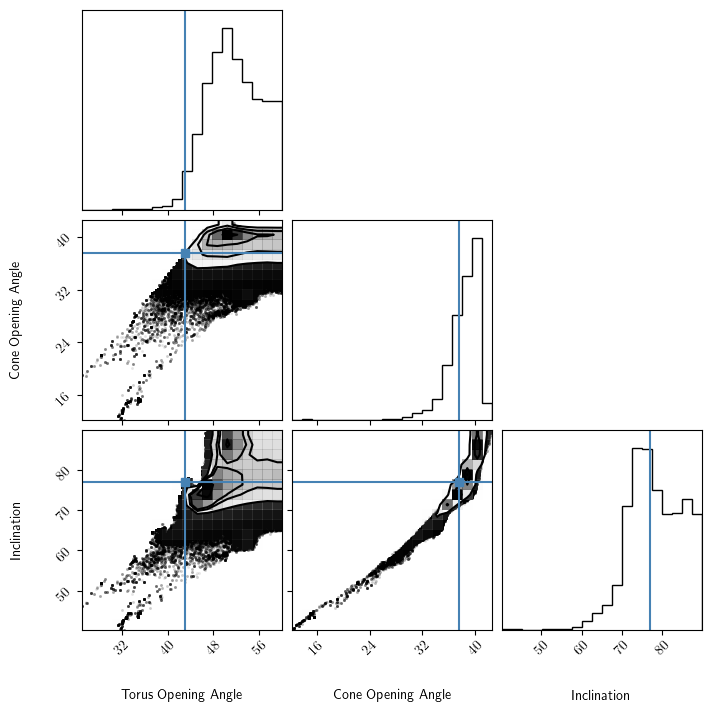

In [16]:
#Run the MCMC
i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
x0 = np.array([tang_grid[i].value, cang_grid[j].value, iang_grid[k].value])

chi2_mod = RegularGridInterpolator((tang_grid.value, cang_grid.value, iang_grid.value), chi2_map[wid], method='linear', bounds_error=False, fill_value=np.inf)

flatchain = run_MCMC(x0)

### Assuming All Lyman Alpha is Unpolarized

In [17]:
#Now, let's assume that all of the Lyalpha flux is unpolarized, which may well be the case as Lyman alpha may be coming from much larger physical scales. Then we need to scale the polarization fraction by the total flux. 
for bname in op.pfrac[wid].keys():
    I_tot = total_flux[bname]
    I_unpol = line_flux[bname]['Lyalpha_narrow'] + line_flux[bname]['Lyalpha_broad']
    I_pol = I_tot - I_unpol

    pol_corr_fact[bname] = I_tot/I_pol
    print("{} {:.3f} {:.3f} {:.3f}".format(bname, pol_corr_fact[bname], op.pfrac[wid][bname]*pol_corr_fact[bname], op.epfrac[wid][bname]*pol_corr_fact[bname]))

R_SPECIAL 1.000 11.110 0.220
I_BESS 1.000 14.360 0.430
v_HIGH 1.412 13.580 0.536


In [18]:
#Get the best-fit values.

wid = "W0116-0505"
chi2_map = get_chi2_map(wid, pol_corr_fact)

i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
print(tang_grid[i], cang_grid[j], iang_grid[k], chi2_map[wid].min())

57.5 deg 22.0 deg 62.0 deg 0.5995959090453851


100%|██████████| 5000/5000 [00:29<00:00, 168.25it/s]


From minimum chi^2
Torus Opening Angle: 57.5 -22.8 +-3.7
Cone Opening Angle: 22.0 -7.9 +5.2
Inclination: 62.0 -19.0 +-1.6
chi^2: [0.59959591]

From median
Torus Opening Angle: 42.0 -7.4 +11.8
Cone Opening Angle: 20.6 -6.5 +6.6
Inclination: 51.4 -8.4 +9.0
chi^2: [35.83576947]

From mean
Torus Opening Angle: 43.4 -8.7 +10.4
Cone Opening Angle: 20.7 -6.7 +6.4
Inclination: 51.5 -8.5 +8.9
chi^2: [87.39589736]



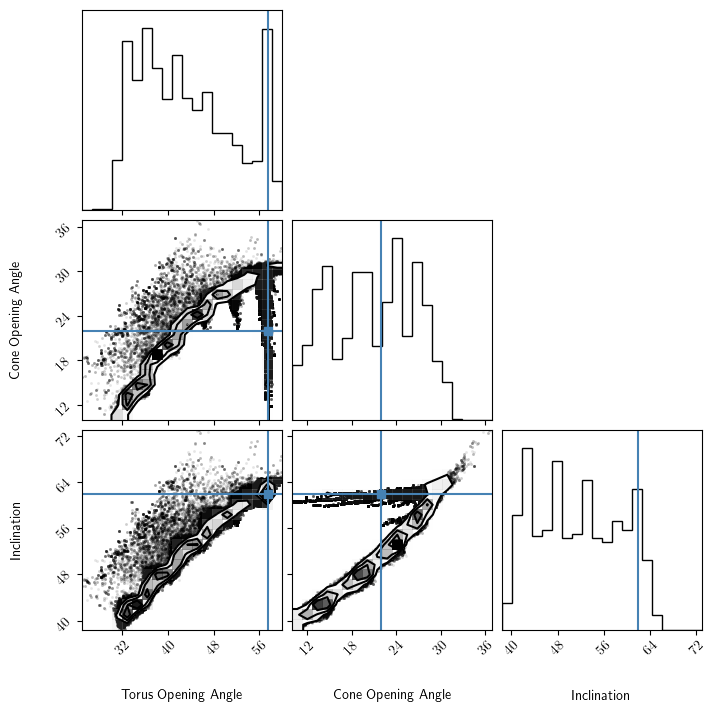

In [19]:
#Run the MCMC
i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
x0 = np.array([tang_grid[i].value, cang_grid[j].value, iang_grid[k].value])

chi2_mod = RegularGridInterpolator((tang_grid.value, cang_grid.value, iang_grid.value), chi2_map[wid], method='linear', bounds_error=False, fill_value=np.inf)

flatchain = run_MCMC(x0)

### Assuming Narrow Lyman Alpha is Unpolarized

In [20]:
for bname in op.pfrac[wid].keys():
    I_tot = total_flux[bname]
    I_unpol = line_flux[bname]['Lyalpha_narrow']
    I_pol = I_tot - I_unpol

    pol_corr_fact[bname] = I_tot/I_pol
    print("{} {:.3f} {:.3f} {:.3f}".format(bname, pol_corr_fact[bname], op.pfrac[wid][bname]*pol_corr_fact[bname], op.epfrac[wid][bname]*pol_corr_fact[bname]))

R_SPECIAL 1.000 11.110 0.220
I_BESS 1.000 14.360 0.430
v_HIGH 1.084 10.428 0.412


In [21]:
#Get the best-fit values.

wid = "W0116-0505"
chi2_map = get_chi2_map(wid, pol_corr_fact)

i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
print(tang_grid[i], cang_grid[j], iang_grid[k], chi2_map[wid].min())

55.0 deg 30.5 deg 62.0 deg 14.271532041920135


100%|██████████| 5000/5000 [00:31<00:00, 160.83it/s]


From minimum chi^2
Torus Opening Angle: 55.0 -13.6 +-0.3
Cone Opening Angle: 30.5 -2.3 +6.3
Inclination: 62.0 -2.9 +11.3
chi^2: [14.27153204]

From median
Torus Opening Angle: 48.8 -7.4 +5.9
Cone Opening Angle: 32.3 -4.0 +4.5
Inclination: 65.2 -6.1 +8.1
chi^2: [22.91300519]

From mean
Torus Opening Angle: 48.1 -6.8 +6.6
Cone Opening Angle: 31.9 -3.6 +4.9
Inclination: 65.5 -6.4 +7.8
chi^2: [22.18329236]



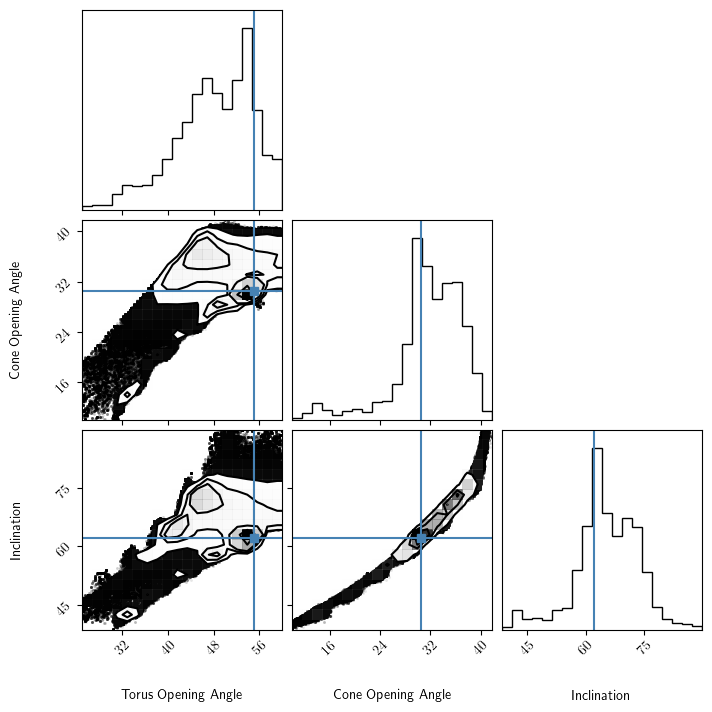

In [22]:
#Run the MCMC
i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
x0 = np.array([tang_grid[i].value, cang_grid[j].value, iang_grid[k].value])

chi2_mod = RegularGridInterpolator((tang_grid.value, cang_grid.value, iang_grid.value), chi2_map[wid], method='linear', bounds_error=False, fill_value=np.inf)

flatchain = run_MCMC(x0)

### Assuming that narrow line is unpolarized and that the broad lines are polarized at the 5% level. 

Here we are actually replacing the pfrac and epfrac values for convenience, so this should always be the last comparison to run.

In [23]:
wid = "W0116-0505"
pol_frac_broadline = 5 #Polarization fraction of the broad emission lines, in %

epol_corr_fact = dict()

for bname in op.pfrac[wid].keys():
    ptot = op.pfrac[wid][bname]
    eptot = op.epfrac[wid][bname]

    fl_tot = 0.
    fl_broad = 0.
    for line_name in line_flux[bname].keys():
        fl_tot += line_flux[bname][line_name]
        if line_name[-5:]=="broad":
            fl_broad += line_flux[bname][line_name]
    fc = total_flux[bname] - fl_tot

    pc = ( ptot * total_flux[bname] - pol_frac_broadline * fl_broad) / fc

    pol_corr_fact[bname] = pc/ptot
    epol_corr_fact[bname] = total_flux[bname]/fc

    print("{} {:.3f} {:.3f} {:.3f}".format(bname, pol_corr_fact[bname], op.pfrac[wid][bname]*pol_corr_fact[bname], op.epfrac[wid][bname]*epol_corr_fact[bname]))

R_SPECIAL 1.179 13.100 0.292
I_BESS 1.000 14.361 0.430
v_HIGH 1.678 16.138 0.845


In [24]:
#Get the best-fit values.

wid = "W0116-0505"
chi2_map = get_chi2_map(wid, pol_corr_fact, epol_corr_fact=epol_corr_fact)

i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
print(tang_grid[i], cang_grid[j], iang_grid[k], chi2_map[wid].min())

53.5 deg 16.5 deg 58.0 deg 0.0823967153851129


100%|██████████| 5000/5000 [00:29<00:00, 168.05it/s]


From minimum chi^2
Torus Opening Angle: 53.5 -15.8 +-5.4
Cone Opening Angle: 16.5 -4.6 +4.7
Inclination: 58.0 -14.2 +-4.4
chi^2: [0.08239672]

From median
Torus Opening Angle: 42.4 -4.6 +5.7
Cone Opening Angle: 16.2 -4.3 +5.0
Inclination: 48.0 -4.1 +5.6
chi^2: [4.1972419]

From mean
Torus Opening Angle: 43.0 -5.3 +5.1
Cone Opening Angle: 16.5 -4.6 +4.7
Inclination: 48.6 -4.8 +5.0
chi^2: [4.99737854]



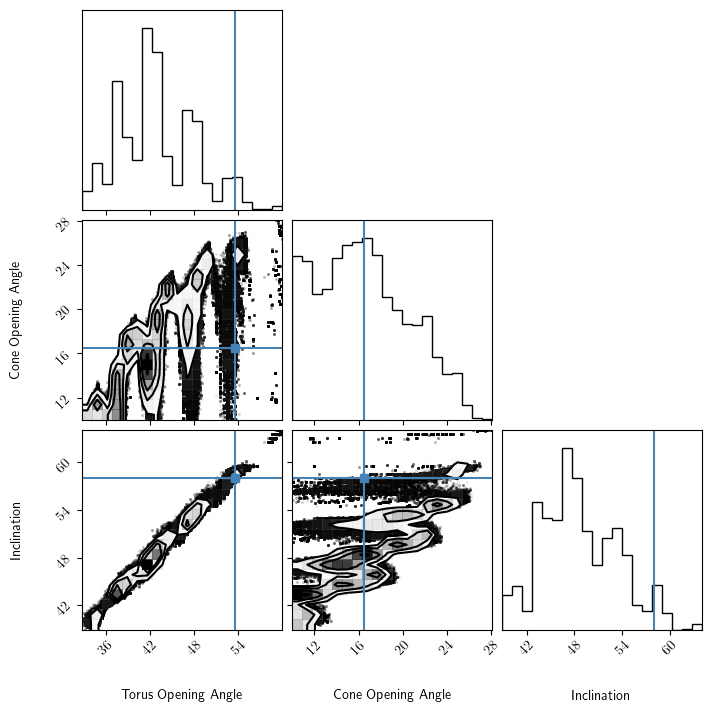

In [25]:
#Run the MCMC
i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
x0 = np.array([tang_grid[i].value, cang_grid[j].value, iang_grid[k].value])

chi2_mod = RegularGridInterpolator((tang_grid.value, cang_grid.value, iang_grid.value), chi2_map[wid], method='linear', bounds_error=False, fill_value=np.inf)

flatchain = run_MCMC(x0)